In [63]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import cross_validate,StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier


In [64]:
data = joblib.load("train_test_data.pkl")

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]


print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (226980, 30)
y_train shape: (226980,)
X_test shape: (56746, 30)
y_test shape: (56746,)


LogisticRegression

In [73]:
lr = LogisticRegression(random_state=42,max_iter=1000)

skf = StratifiedKFold(n_splits=5,random_state=42,shuffle=True,)
scoring = {
    "accuracy": "accuracy",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1"
}

cv_results = cross_validate(
    lr,
    X_train,
    y_train,
    cv = skf,
    scoring=scoring
)


print(f"Accuracy : {cv_results['test_accuracy'].mean():.4f}")
print(f"Precision: {cv_results['test_precision'].mean():.4f}")
print(f"Recall   : {cv_results['test_recall'].mean():.4f}")
print(f"F1       : {cv_results['test_f1'].mean():.4f}")

lr.fit(X_train,y_train)
y_pred_lr = lr.predict(X_test)


Accuracy : 0.9992
Precision: 0.8633
Recall   : 0.6056
F1       : 0.7096


Logistic Regression Evaluation 

accuracy_lr: 0.9991
precision_lr: 0.8462
recall_lr: 0.5789
f1_lr: 0.6875

TN:56641
FN:40
TP:55
FP:10


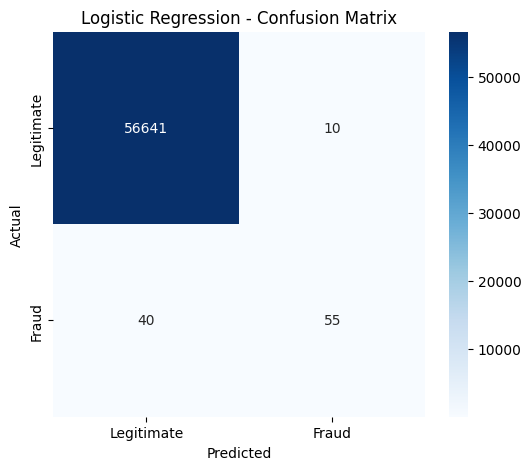

In [74]:
acc_lr = accuracy_score(y_test,y_pred_lr)
pre_lr = precision_score(y_test,y_pred_lr)
recall_lr = recall_score(y_test,y_pred_lr)
f1_lr = f1_score(y_test,y_pred_lr)
cm_lr = confusion_matrix(y_test,y_pred_lr)

print(f"accuracy_lr: {acc_lr:.4f}")
print(f"precision_lr: {pre_lr:.4f}")
print(f"recall_lr: {recall_lr:.4f}")
print(f"f1_lr: {f1_lr:.4f}\n")

TN, FP, FN, TP = cm_lr.ravel()
print(f"TN:{TN}")
print(f"FN:{FN}")
print(f"TP:{TP}")
print(f"FP:{FP}")


plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()